In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words=open('names.txt', 'r').read().splitlines()
print(words[:10:])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
32033


In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#splitting the dataset intro train(80%), dev(10%),test(10%)

def build_dataset(words):
    block_size=8            #no. of elements in our context used to predict the next char 
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]        #updating last (3rd) element in context block


    X=torch.tensor(X)
    Y =torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y


import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xtest,Ytest=build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [6]:
g=torch.Generator().manual_seed(2147483647)

#initializing 10-d embeddings for all 27 of our characters
C=torch.randn((27,30),generator=g)

#creating hyperparamters
W1=torch.randn((240,400),generator=g)
b1=torch.randn((400),generator=g)

W2=torch.randn((400,27),generator=g)*0.01
b2=torch.randn((27),generator=g)

parameters=[C,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad=True    

lossarr=[]    

In [55]:
C[Xtr[20]].view(-1,240).shape

torch.Size([1, 240])

In [ ]:
#backward pass
parameters=[C,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad=True    
#training on a mini batch of the train split

for i in range(20000):
    ix=torch.randint(0,Xtr.shape[0],(1000,))
    emb=C[Xtr[ix]]
    h=torch.tanh(emb.view(-1,240)@ W1 +b1)  #(1000,400)
    logits=h @ W2 +b2    #(1000,27)
    loss=F.cross_entropy(logits,Ytr[ix])

    #gradient descent
    for p in parameters:
        p.grad =None
    loss.backward()

    lr=0.001

    for p in parameters:
        p.data+= -lr * p.grad
    lossarr.append(loss.item())
  #  if loss.item()<1.5:
    #    break 
print(loss.item())         

2.1544768810272217


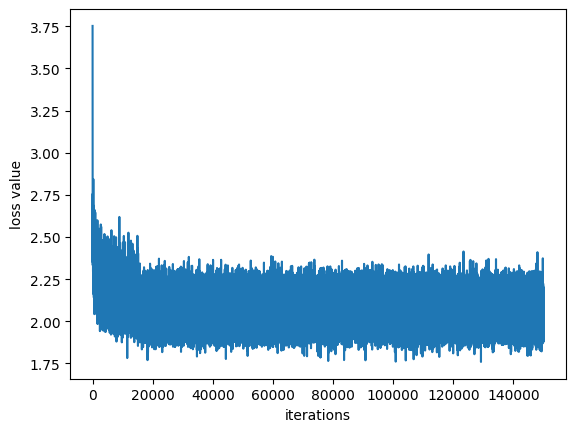

In [40]:
plt.plot(range(len(lossarr)),lossarr)
plt.xlabel("iterations")
plt.ylabel("loss value")
plt.show()

In [39]:
print(min(lossarr))

1.7592006921768188


In [34]:
#loss on the dev dataset after mini batch optimization of training set
emb=C[Xdev]
h=torch.tanh(emb.view(-1,240) @ W1 +b1)
logits= h @ W2 + b2
loss=F.cross_entropy(logits,Ydev)
print(loss.item())


2.148592233657837


In [ ]:
#final loss on the test dataset 
emb=C[Xtest]
h=torch.tanh(emb.view(-1,240) @ W1 +b1)
logits= h @ W2 + b2
loss=F.cross_entropy(logits,Ytest)
print(loss.item())


2.144482135772705


In [ ]:
#sampling from the model
g=torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out =[]
    context=[0]*8
    while True:
        emb=C[torch.tensor([context])]
        h=torch.tanh(emb.view(-1,240)@W1+b1)
        logits=h @ W2 +b2
        probs=F.softmax(logits,dim=1)
        ix=torch.multinomial(probs,num_samples=1,generator=g).item()
        context=context[1:]+[ix]
        out.append(ix)
        if ix==0:
            break

    print(''.join(itos[i]for i in out))            

carmah.
ameli.
kitrim.
shreyty.
skansso.
jazzebe.
deliyra.
kaeli.
nellari.
chaiir.
kaleig.
dham.
jocnies.
juzanoi.
walvie.
quiqaelo.
dearixi.
jaxeini.
sabie.
decoid.
